# Analyse comparative des agents — Bobail (vs Random)

Ce notebook évalue tous les agents entraînés / configurés sur **Bobail (vs Random)** (bobail) selon plusieurs métriques. Bobail est adversarial 2 joueurs (gameplay choisi du syllabus) vs un opponent random. Le reward est +1 / 0 / -1 ; les épisodes peuvent être longs car le but oblige à atteindre la home row de l'adversaire.

## Sources de données

| Source | Mode | Description |
|---|---|---|
| `training_curve.csv` (par run) | TRAINING | Reward épisode-par-épisode pendant l'entraînement (politique ε-greedy en cours d'apprentissage). |
| `metrics_reeval.csv` (par run) | INFERENCE | Re-évaluation par `scripts/evaluate_all.py` : politique gelée à chaque checkpoint, ε=0, argmax greedy. **Source canonique pour les métriques finales.** |
| `metrics.csv` (par run, fallback) | INFERENCE | Eval pendant l'entraînement (mode greedy aussi). Utilisé pour `random` qui n'a pas de checkpoints. |
| `metrics.csv` (planning agents) | INFERENCE | Sweep `budget → score` produit par `scripts/evaluate_planning_agents.py` pour MCTS / RandomRollout. |

> ⚠️ **Attention adversarial** : `metrics_reeval.csv` contient à la fois les colonnes `*_combined` (moyenne pondérée P0+P1) et les colonnes `*_p0` / `*_p1` séparées. Le loader normalise `*_combined` vers les noms de base (`mean_reward`, `win_rate`, etc.). La métrique principale est le **win_rate combined** : pour l'évaluation, l'agent joue moitié des parties en P0 et moitié en P1 contre l'opponent (random par défaut), pour neutraliser l'avantage du premier joueur.

## Plan

1. **Inventaire** des runs disponibles
2. **TRAINING** — courbes d'apprentissage (reward par épisode)
3. **INFERENCE** — Reward combined (P0 + P1) par checkpoint
4. **INFERENCE** — Win / Draw / Loss au dernier checkpoint (stacked bar)
5. **INFERENCE** — Évolution du win_rate par checkpoint (par agent, superposé)
6. **INFERENCE** — Déséquilibre P0 vs P1 (avantage de jouer en premier ?)
7. **INFERENCE** — Longueur d'épisode (steps)
8. **INFERENCE** — Temps moyen par coup (ms)
9. **INFERENCE** — Comparaison aux checkpoints clés (bar chart)
10. **INFERENCE** — Best checkpoint par agent (« plus d'épisodes ≠ meilleur »)
11. **INFERENCE** — Termination vs truncation
12. **PLANNING** — Sweep budget → win_rate / temps pour MCTS et RandomRollout
13. **PARETO** — Temps par coup vs win_rate
14. **Hyperparamètres** de chaque run
15. **Synthèse finale** — ranking par win_rate

> Hypothèse : `uv run scripts/evaluate_all.py --num-games 100` et `uv run scripts/evaluate_planning_agents.py configs_done/{mcts,random_rollout}/bobail.yaml` ont été exécutés.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

# Resolve project root (this notebook lives in notebooks/)
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
RESULTS_DIR = ROOT / "results"

ENV_NAME = "bobail"
ENV_TITLE = "Bobail (vs Random)"
EXPECTED_CHECKPOINTS = [1000, 10000, 50000, 100000]

LEARNING_AGENTS = ["random", "tabular_q", "dqn", "ddqn", "ddqn_er", "ddqn_per"]
PLANNING_AGENTS = ["random_rollout", "mcts"]
ALL_AGENTS_ORDER = LEARNING_AGENTS + PLANNING_AGENTS

cmap = plt.get_cmap("tab10")
AGENT_COLOR = {a: cmap(i % 10) for i, a in enumerate(ALL_AGENTS_ORDER)}

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("ROOT     =", ROOT)
print("ENV      =", ENV_NAME)
print("Results  =", RESULTS_DIR.exists())


ROOT     = /Users/brandontchakaniyungeko/ESGI-dev/5IABD/T2/deep_reinforcement_learning/projet
ENV      = bobail
Results  = True


In [2]:
def discover_runs(env_name: str):
    """Scan results/{env}/{agent}/{run_dir}/ and split learning vs planning runs.

    Skips directories named 'best/' (curated single-checkpoint copies, would duplicate data).
    """
    learning, planning = [], []
    env_path = RESULTS_DIR / env_name
    if not env_path.exists():
        return learning, planning

    for agent_dir in sorted(env_path.iterdir()):
        if not agent_dir.is_dir():
            continue
        agent_name = agent_dir.name
        for run_dir in sorted(agent_dir.iterdir()):
            if not run_dir.is_dir() or run_dir.name == "best":
                continue
            cfg_path = run_dir / "config.yaml"
            if not cfg_path.exists():
                continue
            with open(cfg_path) as f:
                cfg = yaml.safe_load(f) or {}
            entry = {
                "agent": agent_name,
                "run_dir": run_dir,
                "run_name": run_dir.name,
                "seed": cfg.get("seed", ""),
                "config": cfg,
            }
            if run_dir.name.startswith("budget_sweep") or agent_name in PLANNING_AGENTS:
                planning.append(entry)
            else:
                learning.append(entry)
    return learning, planning


def load_training_curve(run_entry):
    p = run_entry["run_dir"] / "training_curve.csv"
    if not p.exists():
        return pd.DataFrame()
    df = pd.read_csv(p)
    df["agent"] = run_entry["agent"]
    df["run_name"] = run_entry["run_name"]
    return df


def load_planning_metrics(run_entry):
    p = run_entry["run_dir"] / "metrics.csv"
    if not p.exists():
        return pd.DataFrame()
    df = pd.read_csv(p)
    df["agent"] = run_entry["agent"]
    df["run_name"] = run_entry["run_name"]
    return df


def load_eval_metrics(run_entry):
    """Adversarial schema. Normalizes *_combined columns to base names so the rest of the
    notebook can use a single column scheme (mean_reward, win_rate, etc.).

    Random has no checkpoints → falls back to metrics.csv (mono-style schema, no win_rate).
    """
    run_dir = run_entry["run_dir"]
    reeval = run_dir / "metrics_reeval.csv"
    fallback = run_dir / "metrics.csv"

    df = None
    is_adversarial_schema = False
    if reeval.exists() and reeval.stat().st_size > 0:
        df = pd.read_csv(reeval)
        if df.empty:
            df = None
        else:
            is_adversarial_schema = "mean_reward_combined" in df.columns
    if df is None and fallback.exists():
        df = pd.read_csv(fallback)
    if df is None or df.empty:
        return pd.DataFrame()

    df = df.copy()

    if is_adversarial_schema:
        # Copy combined → base names (so plots can use unified column names)
        rename = {
            "mean_reward_combined": "mean_reward",
            "mean_steps_combined": "mean_steps",
            "win_rate_combined": "win_rate",
            "draw_rate_combined": "draw_rate",
            "loss_rate_combined": "loss_rate",
            "termination_rate_combined": "termination_rate",
            "truncation_rate_combined": "truncation_rate",
        }
        for src, dst in rename.items():
            if src in df.columns:
                df[dst] = df[src]
    else:
        # Mono-style fallback (random): set adversarial-only cols to NaN so plots skip them
        for col in ["win_rate", "draw_rate", "loss_rate",
                    "win_rate_p0", "win_rate_p1",
                    "mean_reward_p0", "mean_reward_p1"]:
            if col not in df.columns:
                df[col] = np.nan

    df["agent"] = run_entry["agent"]
    df["run_name"] = run_entry["run_name"]
    df["seed"] = run_entry["seed"]
    return df


In [3]:
learning_runs, planning_runs = discover_runs(ENV_NAME)
print(f"Learning runs : {len(learning_runs)}")
for r in learning_runs:
    print(f"  - {r['agent']:10s} seed={r['seed']:<5}  {r['run_name'][:80]}")
print(f"\nPlanning runs : {len(planning_runs)}")
for r in planning_runs:
    print(f"  - {r['agent']:18s} seed={r['seed']:<5}  {r['run_name']}")

eval_frames = [load_eval_metrics(r) for r in learning_runs]
df_eval = pd.concat([f for f in eval_frames if not f.empty], ignore_index=True) if eval_frames else pd.DataFrame()

train_frames = [load_training_curve(r) for r in learning_runs]
df_train = pd.concat([f for f in train_frames if not f.empty], ignore_index=True) if train_frames else pd.DataFrame()

planning_frames = [load_planning_metrics(r) for r in planning_runs]
df_planning = pd.concat([f for f in planning_frames if not f.empty], ignore_index=True) if planning_frames else pd.DataFrame()

print(f"\nINFERENCE eval rows  : {len(df_eval)}")
print(f"TRAINING curve rows  : {len(df_train)}")
print(f"PLANNING sweep rows  : {len(df_planning)}")


Learning runs : 19
  - ddqn       seed=42     batch_size64_buffer_capacity10000_epsilon_decay_steps100000_epsilon_end0.05_epsi
  - ddqn       seed=123    batch_size64_buffer_capacity50000_epsilon_decay_steps100000_epsilon_end0.05_epsi
  - ddqn       seed=42     batch_size64_buffer_capacity50000_epsilon_decay_steps100000_epsilon_end0.05_epsi
  - ddqn       seed=456    batch_size64_buffer_capacity50000_epsilon_decay_steps100000_epsilon_end0.05_epsi
  - ddqn       seed=123    batch_size64_buffer_capacity50000_epsilon_decay_steps80000_epsilon_end0.05_epsil
  - ddqn       seed=42     batch_size64_buffer_capacity50000_epsilon_decay_steps80000_epsilon_end0.05_epsil
  - ddqn_er    seed=42     batch_size64_buffer_capacity50000_epsilon_decay_steps100000_epsilon_end0.05_epsi
  - ddqn_er    seed=123    batch_size64_buffer_capacity50000_epsilon_decay_steps80000_epsilon_end0.05_epsil
  - ddqn_er    seed=42     batch_size64_buffer_capacity50000_epsilon_decay_steps80000_epsilon_end0.05_epsil
  - ddqn_


INFERENCE eval rows  : 66
TRAINING curve rows  : 1461374
PLANNING sweep rows  : 8


## 1. Inventaire des runs

In [4]:
inventory_rows = []
for r in learning_runs + planning_runs:
    cfg = r["config"]
    inventory_rows.append({
        "type": "planning" if r in planning_runs else "learning",
        "agent": r["agent"],
        "seed": r["seed"],
        "n_checkpoints": (
            sum(1 for p in r["run_dir"].glob("model_*.pt"))
            if r in learning_runs else "-"
        ),
        "n_episodes_trained": cfg.get("training", {}).get("num_episodes", "-"),
        "run_name_short": r["run_name"][:60] + ("..." if len(r["run_name"]) > 60 else ""),
    })
inv = pd.DataFrame(inventory_rows)
inv


,type,agent,seed,n_checkpoints,n_episodes_trained,run_name_short
0,learning,ddqn,42,0,100000,batch_size64_buffer_capacity10000_epsilon_deca...
1,learning,ddqn,123,3,100000,batch_size64_buffer_capacity50000_epsilon_deca...
2,learning,ddqn,42,3,100000,batch_size64_buffer_capacity50000_epsilon_deca...
3,learning,ddqn,456,3,100000,batch_size64_buffer_capacity50000_epsilon_deca...
4,learning,ddqn,123,4,100000,batch_size64_buffer_capacity50000_epsilon_deca...
5,learning,ddqn,42,4,100000,batch_size64_buffer_capacity50000_epsilon_deca...
6,learning,ddqn_er,42,3,50000,batch_size64_buffer_capacity50000_epsilon_deca...
7,learning,ddqn_er,123,4,100000,batch_size64_buffer_capacity50000_epsilon_deca...
8,learning,ddqn_er,42,4,100000,batch_size64_buffer_capacity50000_epsilon_deca...
9,learning,ddqn_per,42,3,50000,batch_size64_buffer_capacity50000_epsilon_deca...


## 2. [TRAINING] Courbes d'apprentissage

Reward par épisode pendant l'entraînement (mode ε-greedy, exploration active). On affiche une **moyenne glissante** sur 200 épisodes pour lisser le bruit. Random est plat (ε non pertinent), les Q-learning convergent vers un plateau.

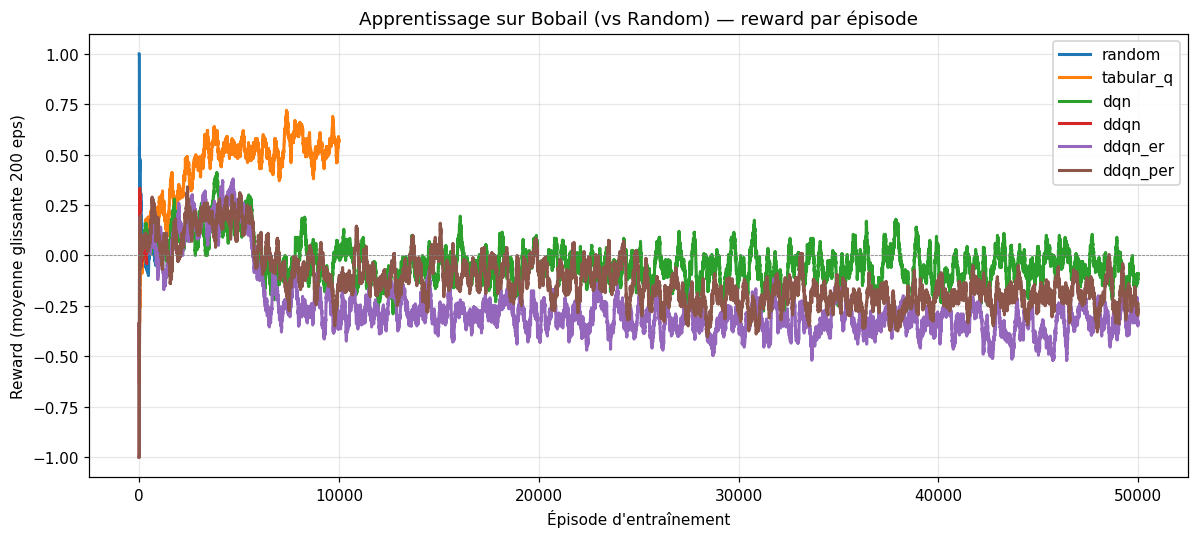

In [5]:
WINDOW = 200

if df_train.empty:
    print("No training curves found.")
else:
    fig, ax = plt.subplots(figsize=(11, 5))
    for agent in [a for a in LEARNING_AGENTS if a in df_train["agent"].unique()]:
        sub = df_train[df_train["agent"] == agent].copy()
        first_run = sub["run_name"].iloc[0]
        sub = sub[sub["run_name"] == first_run].sort_values("episode")
        if len(sub) == 0:
            continue
        smoothed = sub["reward"].rolling(WINDOW, min_periods=1).mean()
        ax.plot(sub["episode"], smoothed, label=agent, color=AGENT_COLOR[agent], linewidth=2)
    ax.set_xlabel("Épisode d'entraînement")
    ax.set_ylabel(f"Reward (moyenne glissante {WINDOW} eps)")
    ax.set_title(f"Apprentissage sur {ENV_TITLE} — reward par épisode")
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.legend(loc="best", framealpha=0.9)
    plt.tight_layout()
    plt.show()


## 3. [INFERENCE] Reward moyen par checkpoint

Politique gelée, 100 parties par checkpoint. Une courbe par agent. **Si la courbe descend après un certain checkpoint → l'agent a régressé** (overfit, instabilité, divergence).

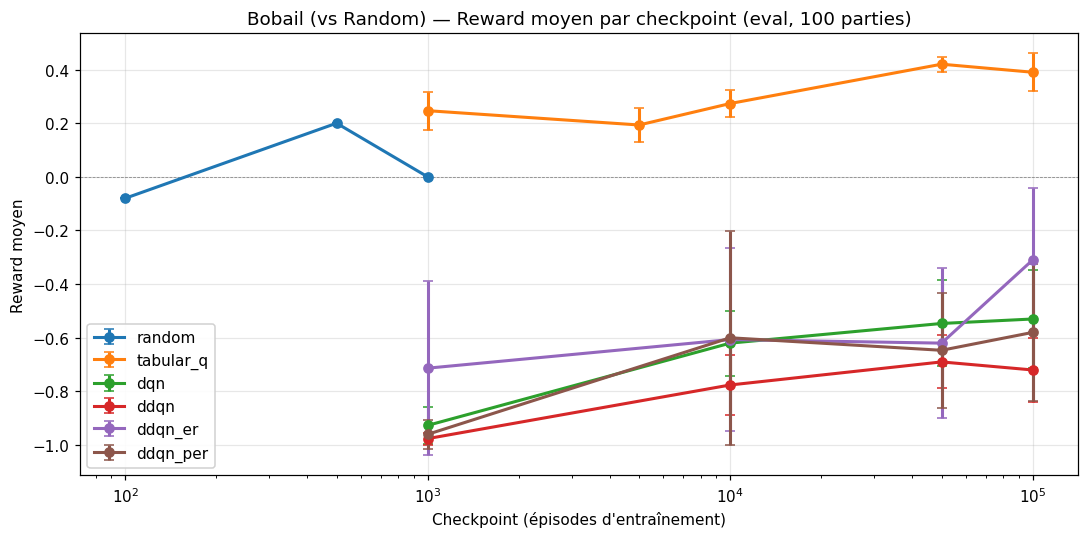

In [6]:
if df_eval.empty:
    print("No eval data.")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    for agent in [a for a in LEARNING_AGENTS if a in df_eval["agent"].unique()]:
        sub = df_eval[df_eval["agent"] == agent].sort_values("checkpoint")
        # Average across seeds if multiple
        agg = sub.groupby("checkpoint", as_index=False).agg(
            mean_reward=("mean_reward", "mean"),
            std_reward=("mean_reward", "std"),
        ).fillna(0)
        ax.errorbar(
            agg["checkpoint"], agg["mean_reward"],
            yerr=agg["std_reward"],
            label=agent, color=AGENT_COLOR[agent], marker="o", capsize=3, linewidth=2,
        )
    ax.set_xlabel("Checkpoint (épisodes d'entraînement)")
    ax.set_ylabel("Reward moyen")
    ax.set_title(f"{ENV_TITLE} — Reward moyen par checkpoint (eval, 100 parties)")
    ax.set_xscale("log")
    ax.legend(loc="best", framealpha=0.9)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    plt.tight_layout()
    plt.show()


## 4. [INFERENCE] Win / Draw / Loss au dernier checkpoint

Décomposition victoire / nul / défaite (combined P0+P1) au plus gros checkpoint de chaque agent. Plus la barre verte (win) est haute, mieux c'est. Random est typiquement ~50% en draw sur TicTacToe (effet symétrique).

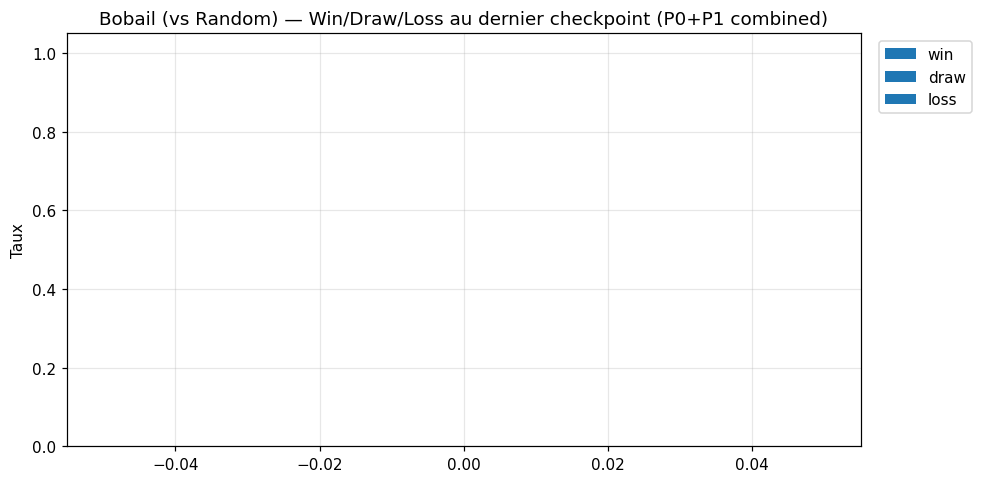

,win_rate,draw_rate,loss_rate
agent,,,


In [7]:
if df_eval.empty or "win_rate" not in df_eval.columns:
    print("No win_rate columns (single-player env or random fallback).")
else:
    last = (df_eval.dropna(subset=["win_rate"])
            .sort_values("checkpoint").groupby("agent").tail(1))
    last = last.set_index("agent").reindex(
        [a for a in LEARNING_AGENTS if a in last.index])
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(last.index, last["win_rate"], color="#4CAF50",
           label="win", edgecolor="black")
    ax.bar(last.index, last["draw_rate"], bottom=last["win_rate"],
           color="#FFC107", label="draw", edgecolor="black")
    ax.bar(last.index, last["loss_rate"],
           bottom=last["win_rate"] + last["draw_rate"],
           color="#F44336", label="loss", edgecolor="black")
    for i, agent in enumerate(last.index):
        ax.text(i, last.loc[agent, "win_rate"] / 2,
                f"{last.loc[agent, 'win_rate']:.0%}",
                ha="center", va="center", fontsize=9, fontweight="bold", color="white")
    ax.set_ylabel("Taux")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{ENV_TITLE} — Win/Draw/Loss au dernier checkpoint (P0+P1 combined)")
    ax.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
    plt.tight_layout()
    plt.show()
    display(last[["win_rate", "draw_rate", "loss_rate"]].round(3))


## 5. [INFERENCE] Évolution du win_rate par checkpoint

Identique à la section reward mais ciblée sur le **win_rate**, qui est la métrique vraiment pertinente pour des jeux. Le reward peut masquer une distribution win/draw/loss différente (ex: deux agents au même reward, l'un gagne souvent et perd souvent, l'autre fait beaucoup de nuls).

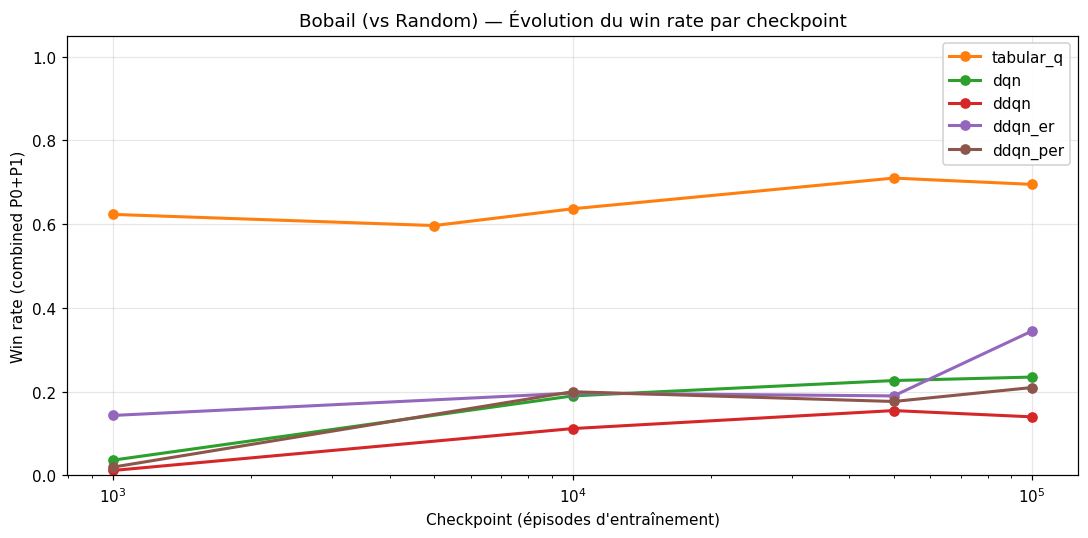

In [8]:
if df_eval.empty or "win_rate" not in df_eval.columns:
    print("No win_rate columns.")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    for agent in [a for a in LEARNING_AGENTS if a in df_eval["agent"].unique()]:
        sub = df_eval[df_eval["agent"] == agent].dropna(subset=["win_rate"])
        if sub.empty:
            continue
        agg = sub.groupby("checkpoint", as_index=False)["win_rate"].mean()
        ax.plot(agg["checkpoint"], agg["win_rate"],
                label=agent, color=AGENT_COLOR[agent], marker="o", linewidth=2)
    ax.set_xlabel("Checkpoint (épisodes d'entraînement)")
    ax.set_ylabel("Win rate (combined P0+P1)")
    ax.set_title(f"{ENV_TITLE} — Évolution du win rate par checkpoint")
    ax.set_xscale("log")
    ax.set_ylim(0, 1.05)
    ax.legend(loc="best", framealpha=0.9)
    plt.tight_layout()
    plt.show()


## 6. [INFERENCE] Déséquilibre P0 vs P1

Quand l'agent joue **en premier (P0)** vs **en second (P1)**, les win_rate doivent être proches si l'agent a appris une politique robuste. Un fort écart indique :
- soit un avantage structurel du premier joueur dans le jeu (TicTacToe avantage P0),
- soit un agent qui a sur-appris une seule perspective (P0 par défaut pendant le training).

C'est exactement ce que `evaluate_both_sides` détecte ([evaluator.py:76](../evaluation/evaluator.py#L76)).

In [9]:
if df_eval.empty or "win_rate_p0" not in df_eval.columns:
    print("No P0/P1 split columns.")
else:
    last = (df_eval.dropna(subset=["win_rate_p0"])
            .sort_values("checkpoint").groupby("agent").tail(1))
    last = last.set_index("agent").reindex(
        [a for a in LEARNING_AGENTS if a in last.index])
    if last.empty:
        print("No P0/P1 data at last checkpoints.")
    else:
        fig, ax = plt.subplots(figsize=(10, 4.5))
        x = np.arange(len(last))
        w = 0.35
        ax.bar(x - w/2, last["win_rate_p0"], w, label="P0 (joue en 1er)",
               color="#1976D2", edgecolor="black")
        ax.bar(x + w/2, last["win_rate_p1"], w, label="P1 (joue en 2nd)",
               color="#FB8C00", edgecolor="black")
        for i, agent in enumerate(last.index):
            ax.text(i - w/2, last.loc[agent, "win_rate_p0"],
                    f"{last.loc[agent, 'win_rate_p0']:.0%}",
                    ha="center", va="bottom", fontsize=8)
            ax.text(i + w/2, last.loc[agent, "win_rate_p1"],
                    f"{last.loc[agent, 'win_rate_p1']:.0%}",
                    ha="center", va="bottom", fontsize=8)
        ax.set_xticks(x)
        ax.set_xticklabels(last.index)
        ax.set_ylabel("Win rate")
        ax.set_ylim(0, 1.1)
        ax.set_title(f"{ENV_TITLE} — Win rate par côté (dernier checkpoint)")
        ax.legend()
        plt.tight_layout()
        plt.show()
        delta = (last["win_rate_p0"] - last["win_rate_p1"]).rename("p0_minus_p1")
        display(pd.concat([last[["win_rate_p0", "win_rate_p1"]], delta], axis=1).round(3))


No P0/P1 data at last checkpoints.


## 7. [INFERENCE] Longueur d'épisode (steps)

Combien de pas faut-il à l'agent pour finir un épisode (en moyenne sur 100 parties).

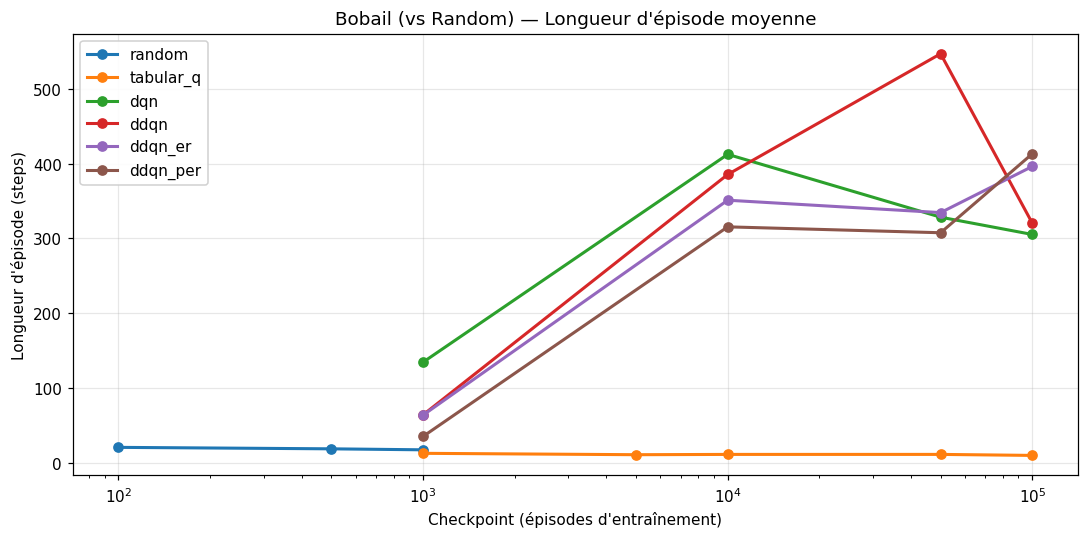

In [10]:
if df_eval.empty:
    print("No eval data.")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    for agent in [a for a in LEARNING_AGENTS if a in df_eval["agent"].unique()]:
        sub = df_eval[df_eval["agent"] == agent].sort_values("checkpoint")
        agg = sub.groupby("checkpoint", as_index=False)["mean_steps"].mean()
        ax.plot(agg["checkpoint"], agg["mean_steps"],
                label=agent, color=AGENT_COLOR[agent], marker="o", linewidth=2)
    ax.set_xlabel("Checkpoint (épisodes d'entraînement)")
    ax.set_ylabel("Longueur d'épisode (steps)")
    ax.set_title(f"{ENV_TITLE} — Longueur d'épisode moyenne")
    ax.set_xscale("log")
    ax.legend(loc="best", framealpha=0.9)
    plt.tight_layout()
    plt.show()


## 8. [INFERENCE] Temps par coup (ms)

Latence d'inférence : combien de temps prend `agent.act(state)`. C'est la métrique demandée par le syllabus (« temps moyen mis pour exécuter un coup »).

On affiche le temps moyen au **dernier checkpoint** de chaque agent apprenant.

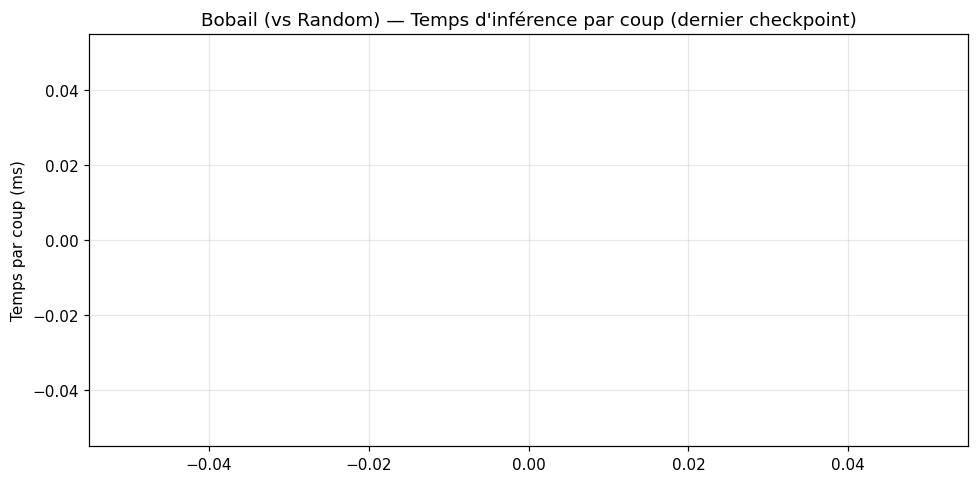

,mean_action_time_ms
agent,


In [11]:
if df_eval.empty:
    print("No eval data.")
else:
    last = df_eval.sort_values("checkpoint").groupby("agent").tail(1)
    last = last.set_index("agent").reindex([a for a in LEARNING_AGENTS if a in last.index])
    fig, ax = plt.subplots(figsize=(9, 4.5))
    bars = ax.bar(last.index, last["mean_action_time_ms"],
                  color=[AGENT_COLOR[a] for a in last.index], edgecolor="black")
    for b, v in zip(bars, last["mean_action_time_ms"]):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.3f}",
                ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("Temps par coup (ms)")
    ax.set_title(f"{ENV_TITLE} — Temps d'inférence par coup (dernier checkpoint)")
    plt.tight_layout()
    plt.show()
    display(last[["mean_action_time_ms"]].round(4))


## 9. [INFERENCE] Comparaison aux checkpoints du syllabus

Bar chart groupé : **Win rate (combined)** pour chaque agent à chaque checkpoint clé. C'est le format direct demandé par le prof.

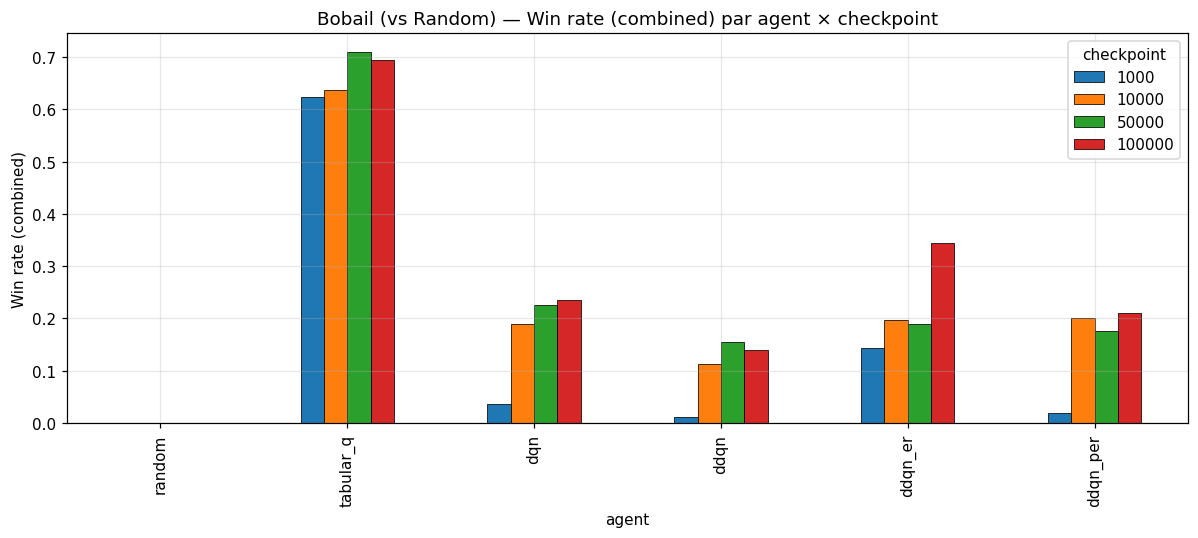

checkpoint,1000,10000,50000,100000
agent,,,,
random,NaN,NaN,NaN,NaN
tabular_q,0.6230,0.6370,0.7100,0.6950
dqn,0.0370,0.1900,0.2270,0.2350
ddqn,0.0120,0.1120,0.1550,0.1400
ddqn_er,0.1430,0.1970,0.1900,0.3450
ddqn_per,0.0200,0.2000,0.1770,0.2100


In [12]:
if df_eval.empty:
    print("No eval data.")
else:
    available = sorted(set(df_eval["checkpoint"].unique()) & set(EXPECTED_CHECKPOINTS))
    if not available:
        print("Aucun des checkpoints attendus n'est présent.")
    else:
        present_agents = [a for a in LEARNING_AGENTS if a in df_eval["agent"].unique()]
        pivot = (df_eval[df_eval["checkpoint"].isin(available)]
                 .pivot_table(index="agent", columns="checkpoint",
                              values="win_rate", aggfunc="mean")
                 .reindex(present_agents))
        ax = pivot.plot(kind="bar", figsize=(11, 5),
                        edgecolor="black", linewidth=0.5)
        ax.set_ylabel("Win rate (combined)")
        ax.set_title(f"{ENV_TITLE} — Win rate (combined) par agent × checkpoint")
        ax.legend(title="checkpoint", loc="best")
        ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
        plt.tight_layout()
        plt.show()
        display(pivot.round(3))


## 10. [INFERENCE] Best checkpoint par agent

**« Plus d'épisodes ≠ meilleur résultat. »** Pour chaque agent on identifie le checkpoint qui maximise le **win_rate** (ties cassés par longueur d'épisode plus courte). Cela permet de détecter les agents qui régressent en fin d'entraînement.

,best_checkpoint,best_win_rate,best_steps,last_checkpoint,last_win_rate,regressed?
agent,,,,,,
tabular_q,100000,0.7200,9.4000,100000,0.6700,YES
dqn,50000,0.3100,373.0300,100000,0.1700,YES
ddqn,10000,0.2100,277.2300,100000,0.0800,YES
ddqn_er,100000,0.4400,263.8400,100000,0.4400,no
ddqn_per,10000,0.4300,327.3700,100000,0.1200,YES


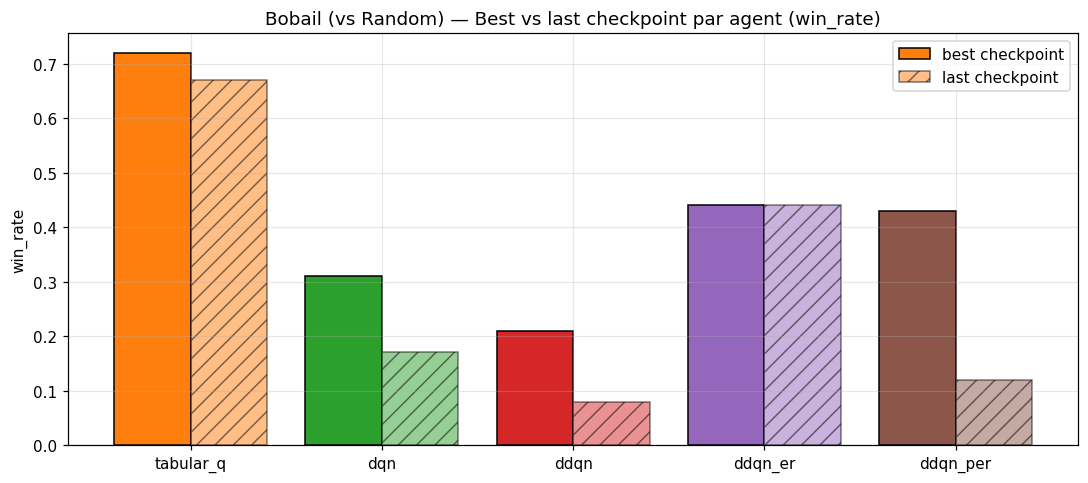

In [13]:
if df_eval.empty:
    print("No eval data.")
else:
    best_rows = []
    for agent in [a for a in LEARNING_AGENTS if a in df_eval["agent"].unique()]:
        sub = df_eval[df_eval["agent"] == agent].copy()
        sub = sub.sort_values(["win_rate", "mean_steps"], ascending=[False, True])
        if sub["win_rate"].dropna().empty:
            continue
        best = sub.iloc[0]
        last = df_eval[df_eval["agent"] == agent].sort_values("checkpoint").iloc[-1]
        best_rows.append({
            "agent": agent,
            "best_checkpoint": int(best["checkpoint"]),
            f"best_win_rate": best["win_rate"],
            "best_steps": best["mean_steps"],
            "last_checkpoint": int(last["checkpoint"]),
            f"last_win_rate": last["win_rate"],
            "regressed?": "YES" if best["win_rate"] > last["win_rate"] + 1e-6 else "no",
        })
    if not best_rows:
        print("Pas de données exploitable pour win_rate.")
    else:
        best_df = pd.DataFrame(best_rows).set_index("agent")
        display(best_df.round(4))

        fig, ax = plt.subplots(figsize=(10, 4.5))
        x = np.arange(len(best_df))
        w = 0.4
        ax.bar(x - w/2, best_df[f"best_win_rate"], w, label="best checkpoint",
               color=[AGENT_COLOR[a] for a in best_df.index], edgecolor="black")
        ax.bar(x + w/2, best_df[f"last_win_rate"], w, label="last checkpoint",
               color=[AGENT_COLOR[a] for a in best_df.index],
               alpha=0.5, edgecolor="black", hatch="//")
        ax.set_xticks(x)
        ax.set_xticklabels(best_df.index)
        ax.set_ylabel("win_rate")
        ax.set_title(f"{ENV_TITLE} — Best vs last checkpoint par agent (win_rate)")
        ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
        ax.legend()
        plt.tight_layout()
        plt.show()


## 11. [INFERENCE] Termination vs truncation

- **terminated** : la partie s'est finie proprement (`done=True`) avant la limite `max_steps=10_000`.
- **truncated** : la politique est restée bloquée et l'évaluateur a dû couper.

Un agent qui « gagne 0% des parties » à cause de truncation est très différent d'un agent qui perd réellement.

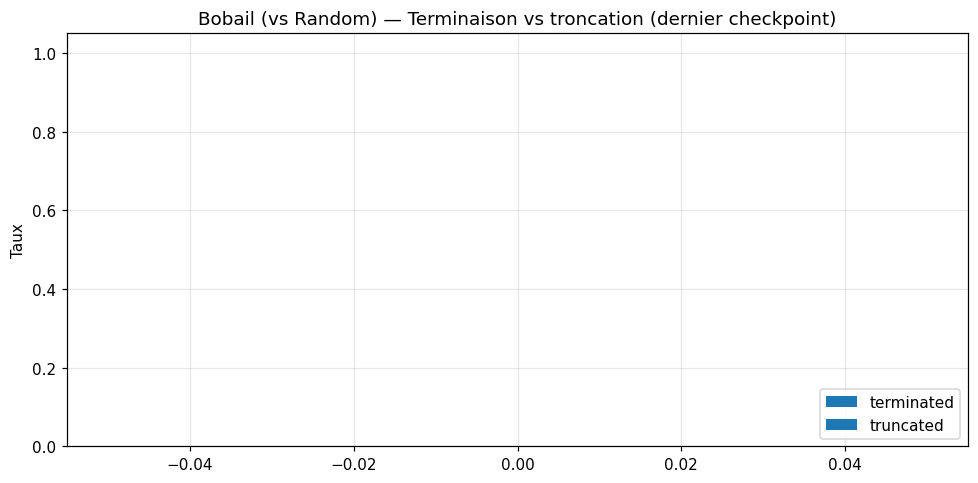

,termination_rate,truncation_rate
agent,,


In [14]:
if df_eval.empty:
    print("No eval data.")
else:
    last = df_eval.sort_values("checkpoint").groupby("agent").tail(1)
    last = last.set_index("agent").reindex([a for a in LEARNING_AGENTS if a in last.index])
    if "termination_rate" not in last.columns:
        print("Pas de colonne termination_rate.")
    else:
        last = last.fillna({"termination_rate": 0, "truncation_rate": 0})
        fig, ax = plt.subplots(figsize=(9, 4.5))
        ax.bar(last.index, last["termination_rate"], label="terminated",
               color="#4CAF50", edgecolor="black")
        ax.bar(last.index, last["truncation_rate"],
               bottom=last["termination_rate"], label="truncated",
               color="#F44336", edgecolor="black")
        ax.set_ylabel("Taux")
        ax.set_ylim(0, 1.05)
        ax.set_title(f"{ENV_TITLE} — Terminaison vs troncation (dernier checkpoint)")
        ax.legend(loc="lower right")
        plt.tight_layout()
        plt.show()
        display(last[["termination_rate", "truncation_rate"]].round(3))


## 12. [PLANNING] MCTS et RandomRollout — sweep budget

Les agents de planification ne s'entraînent pas. Leur axe pertinent est le **budget de simulations par coup**. On observe :
- l'amélioration du Win rate avec le budget (jusqu'à saturation),
- l'augmentation linéaire du temps par coup (= le coût direct de la planification).

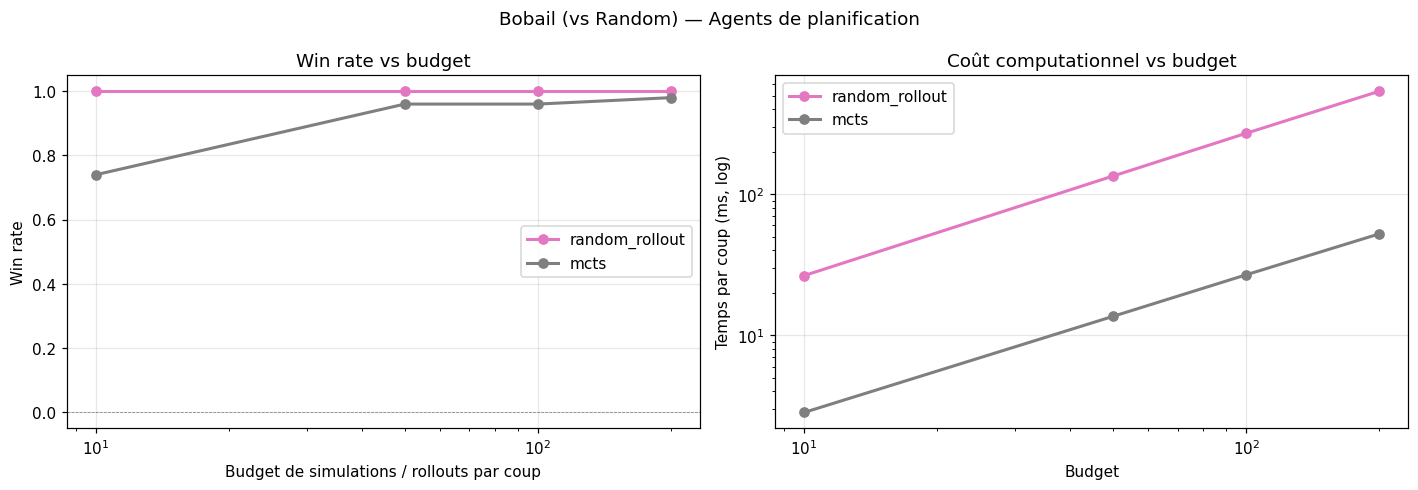

,agent,budget,win_rate,mean_steps,mean_action_time_ms
0,mcts,10,0.7400,12.8000,2.8360
1,mcts,50,0.9600,9.2400,13.6130
2,mcts,100,0.9600,11.2400,26.8080
3,mcts,200,0.9800,10.1600,52.2880
4,random_rollout,10,1.0000,10.6800,26.4690
5,random_rollout,50,1.0000,8.4400,134.4420
6,random_rollout,100,1.0000,9.4000,270.0150
7,random_rollout,200,1.0000,8.9200,536.3140


In [15]:
if df_planning.empty:
    print("Pas de données planning. Lance:")
    print("  uv run scripts/evaluate_planning_agents.py configs_done/mcts/" + ENV_NAME + ".yaml")
    print("  uv run scripts/evaluate_planning_agents.py configs_done/random_rollout/" + ENV_NAME + ".yaml")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for agent in [a for a in PLANNING_AGENTS if a in df_planning["agent"].unique()]:
        sub = df_planning[df_planning["agent"] == agent].sort_values("budget")
        if "win_rate" not in sub.columns or sub["win_rate"].isna().all():
            continue
        axes[0].plot(sub["budget"], sub["win_rate"],
                     label=agent, color=AGENT_COLOR[agent], marker="o", linewidth=2)
        axes[1].plot(sub["budget"], sub["mean_action_time_ms"],
                     label=agent, color=AGENT_COLOR[agent], marker="o", linewidth=2)
    axes[0].set_xscale("log")
    axes[0].set_xlabel("Budget de simulations / rollouts par coup")
    axes[0].set_ylabel("Win rate")
    axes[0].set_title("Win rate vs budget")
    axes[0].legend()
    axes[0].axhline(0, color="gray", linewidth=0.5, linestyle="--")
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Budget")
    axes[1].set_ylabel("Temps par coup (ms, log)")
    axes[1].set_title("Coût computationnel vs budget")
    axes[1].legend()
    plt.suptitle(f"{ENV_TITLE} — Agents de planification")
    plt.tight_layout()
    plt.show()
    cols = ["agent", "budget", "win_rate", "mean_steps", "mean_action_time_ms"]
    cols = [c for c in cols if c in df_planning.columns]
    display(df_planning[cols].sort_values(["agent", "budget"]).reset_index(drop=True))


## 13. [PARETO] Compromis temps/coup vs Win rate

Chaque point = un (agent, checkpoint ou budget). On cherche le coin **haut-gauche** : Win rate élevé, temps faible. C'est utile pour un déploiement temps-réel.

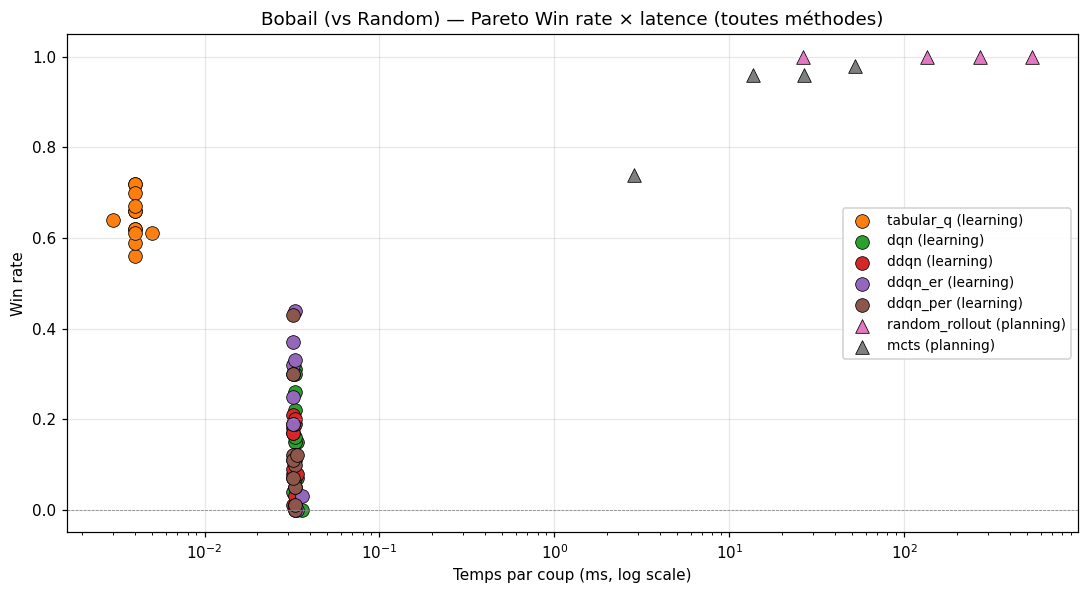

In [16]:
fig, ax = plt.subplots(figsize=(10, 5.5))

if not df_eval.empty and "win_rate" in df_eval.columns:
    for agent in [a for a in LEARNING_AGENTS if a in df_eval["agent"].unique()]:
        sub = df_eval[df_eval["agent"] == agent].dropna(subset=["win_rate"])
        if sub.empty:
            continue
        ax.scatter(sub["mean_action_time_ms"], sub["win_rate"],
                   s=80, color=AGENT_COLOR[agent], label=f"{agent} (learning)",
                   edgecolor="black", linewidth=0.5)

if not df_planning.empty:
    for agent in [a for a in PLANNING_AGENTS if a in df_planning["agent"].unique()]:
        sub = df_planning[df_planning["agent"] == agent]
        if "win_rate" not in sub.columns or sub["win_rate"].isna().all():
            continue
        ax.scatter(sub["mean_action_time_ms"], sub["win_rate"],
                   s=80, color=AGENT_COLOR[agent], label=f"{agent} (planning)",
                   marker="^", edgecolor="black", linewidth=0.5)

ax.set_xscale("log")
ax.set_xlabel("Temps par coup (ms, log scale)")
ax.set_ylabel("Win rate")
ax.set_title(f"{ENV_TITLE} — Pareto Win rate × latence (toutes méthodes)")
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.legend(loc="best", fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()


## 14. Hyperparamètres de chaque run

Snapshot des hyperparamètres tels qu'utilisés pendant l'entraînement (lus depuis `results/<env>/<agent>/<run>/config.yaml`).

In [17]:
hparam_rows = []
for r in learning_runs + planning_runs:
    cfg = r["config"]
    flat = {"agent": r["agent"], "seed": cfg.get("seed", "")}
    for k, v in cfg.get("agent_params", {}).items():
        flat[f"ap.{k}"] = v
    if "training" in cfg:
        flat["num_episodes"] = cfg["training"].get("num_episodes", "")
    if "budgets" in cfg:
        flat["budgets"] = str(cfg["budgets"])
    hparam_rows.append(flat)
hp = pd.DataFrame(hparam_rows).set_index("agent")
hp


,seed,ap.batch_size,ap.buffer_capacity,ap.epsilon_decay_steps,ap.epsilon_end,ap.epsilon_start,ap.gamma,ap.hidden_layers,ap.lr,ap.target_update_freq,...,ap.learning_starts,ap.per_alpha,ap.per_beta_end,ap.per_beta_start,ap.per_beta_steps,ap.c_uct,ap.max_rollout_depth,ap.n_simulations,budgets,ap.n_rollouts_per_action
agent,,,,,,,,,,,,,,,,,,,,,
ddqn,42,64.0000,10000.0000,100000.0000,0.0500,1.0000,0.9900,"[256, 128]",0.0005,200.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ddqn,123,64.0000,50000.0000,100000.0000,0.0500,1.0000,0.9900,"[256, 128]",0.0005,500.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ddqn,42,64.0000,50000.0000,100000.0000,0.0500,1.0000,0.9900,"[256, 128]",0.0005,500.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ddqn,456,64.0000,50000.0000,100000.0000,0.0500,1.0000,0.9900,"[256, 128]",0.0005,500.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ddqn,123,64.0000,50000.0000,80000.0000,0.0500,1.0000,0.9900,"[256, 128]",0.0001,1000.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ddqn,42,64.0000,50000.0000,80000.0000,0.0500,1.0000,0.9900,"[256, 128]",0.0001,1000.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ddqn_er,42,64.0000,50000.0000,100000.0000,0.0500,1.0000,0.9900,"[256, 128]",0.0005,500.0000,...,5000.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ddqn_er,123,64.0000,50000.0000,80000.0000,0.0500,1.0000,0.9900,"[256, 128]",0.0001,1000.0000,...,5000.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ddqn_er,42,64.0000,50000.0000,80000.0000,0.0500,1.0000,0.9900,"[256, 128]",0.0001,1000.0000,...,5000.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 15. Synthèse — ranking final par win_rate

Tableau trié par **win_rate** (au best checkpoint pour les apprenants, au plus gros budget pour planning). On rapporte aussi le temps par coup pour départager.

In [18]:
rows = []

if not df_eval.empty and "win_rate" in df_eval.columns:
    for agent in [a for a in LEARNING_AGENTS if a in df_eval["agent"].unique()]:
        sub = df_eval[df_eval["agent"] == agent].dropna(subset=["win_rate"]).copy()
        if sub.empty:
            continue
        sub = sub.sort_values(["win_rate", "mean_steps"], ascending=[False, True])
        best = sub.iloc[0]
        rows.append({
            "method": agent,
            "kind": "learning",
            "config_point": f"ckpt={int(best['checkpoint'])}",
            "win_rate": best["win_rate"],
            "mean_reward": best.get("mean_reward", float("nan")),
            "mean_steps": best["mean_steps"],
            "mean_action_time_ms": best["mean_action_time_ms"],
            "termination_rate": best.get("termination_rate", float("nan")),
        })

if not df_planning.empty:
    for agent in [a for a in PLANNING_AGENTS if a in df_planning["agent"].unique()]:
        sub = df_planning[df_planning["agent"] == agent].copy()
        if "win_rate" not in sub.columns or sub["win_rate"].isna().all():
            continue
        sub = sub.sort_values(["win_rate", "budget"], ascending=[False, True])
        best = sub.iloc[0]
        rows.append({
            "method": agent,
            "kind": "planning",
            "config_point": f"budget={int(best['budget'])}",
            "win_rate": best["win_rate"],
            "mean_reward": best.get("mean_reward", float("nan")),
            "mean_steps": best["mean_steps"],
            "mean_action_time_ms": best["mean_action_time_ms"],
            "termination_rate": best.get("termination_rate", float("nan")),
        })

if not rows:
    print("No data to rank.")
else:
    ranking = pd.DataFrame(rows).sort_values(
        ["win_rate", "mean_action_time_ms"], ascending=[False, True]
    ).reset_index(drop=True)
    ranking.index = ranking.index + 1
    ranking.index.name = "rank"
    display(ranking.round(4))


,method,kind,config_point,win_rate,mean_reward,mean_steps,mean_action_time_ms,termination_rate
rank,,,,,,,,
1,random_rollout,planning,budget=10,1.0000,1.0000,10.6800,26.4690,1.0000
2,mcts,planning,budget=200,0.9800,0.9600,10.1600,52.2880,1.0000
3,tabular_q,learning,ckpt=100000,0.7200,0.4400,9.4000,0.0040,1.0000
4,ddqn_er,learning,ckpt=100000,0.4400,-0.1200,263.8400,0.0330,1.0000
5,ddqn_per,learning,ckpt=10000,0.4300,-0.1400,327.3700,0.0320,1.0000
6,dqn,learning,ckpt=50000,0.3100,-0.3800,373.0300,0.0330,1.0000
7,ddqn,learning,ckpt=10000,0.2100,-0.5800,277.2300,0.0320,1.0000
